<a href="https://colab.research.google.com/github/fatimabytheway/My-first-ML-Project-/blob/main/ml_projects_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/modified_placement_data.csv")

In [ ]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [ ]:
df.shape

(100, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df['placement_numeric'] = df['placement'].apply(lambda x: 1 if x == 'Yes' else 0)

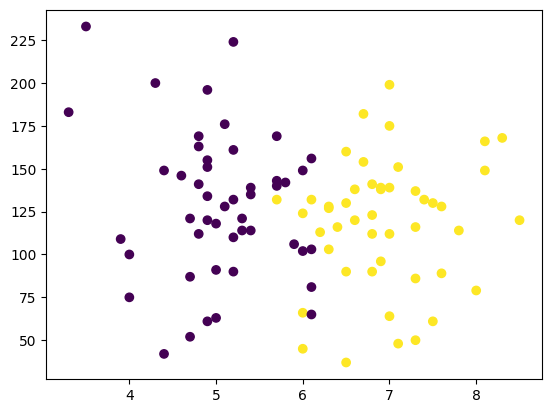

In [ ]:
df['cgpa'] = df['cgpa'].str.replace(',', '.').astype(float)
plt.scatter(df['cgpa'], df['iq'], c=df['placement_numeric'])

In [ ]:
#Making different independent and dependent variables.
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement_numeric
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scalar = StandardScaler()

In [ ]:
X_train=scalar.fit_transform(X_train)

In [ ]:
X_train

array([[ 0.56333584,  1.47733235],
       [-0.29479223,  0.17889571],
       [ 2.10796636, -0.13272908],
       [-0.98129468, -0.13272908],
       [-0.72385626, -0.91179106],
       [ 1.16402548,  0.17889571],
       [ 1.3356511 , -0.93775979],
       [-0.72385626, -0.39241641],
       [-0.03735381, -1.53504065],
       [ 0.048459  ,  0.8021453 ],
       [ 0.22008461,  0.04905205],
       [ 1.50727671, -0.28854147],
       [-0.03735381,  0.62036417],
       [-0.29479223,  1.13973882],
       [-0.55223065,  0.25680191],
       [-0.72385626,  2.56801912],
       [        nan,  0.85408277],
       [ 1.24983829,  0.12695825],
       [ 0.048459  , -0.57419753],
       [ 1.07821268, -1.95054037],
       [ 0.47752303,  0.33470811],
       [ 1.07821268, -1.01566599],
       [-0.63804346, -0.28854147],
       [ 0.64914864, -0.34047894],
       [ 1.07821268, -0.23660401],
       [-2.35429959,  1.50330108],
       [        nan,  1.06183263],
       [ 0.64914864,  0.41261431],
       [-0.63804346,

In [ ]:
X_test=scalar.fit_transform(X_test)

In [ ]:
X_test

array([[ 1.65717794, -0.96788312],
       [-1.36605208,  1.90618029],
       [ 0.6494346 , -0.9467503 ],
       [-1.03013764,  0.76500805],
       [ 1.09732053,  0.42688295],
       [ 0.76140608,  0.06762502],
       [-0.80619467,  1.12426598],
       [-0.58225171, -0.98901594],
       [ 0.53746311, -0.16483599],
       [-0.91816615, -1.22147695]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
#Model training
# Convert X_train to DataFrame to use fillna and then back to numpy array
X_train_imputed = pd.DataFrame(X_train).fillna(pd.DataFrame(X_train).mean()).values
clf.fit(X_train_imputed, y_train)

LogisticRegression()

In [ ]:
#Evaluate teh model.
y_pred = clf.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
y_test

,placement_numeric
16,0
23,0
12,0
8,0
43,1
86,0
39,0
32,1
74,1
45,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

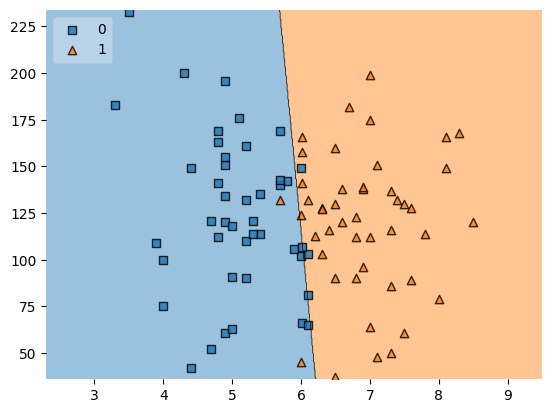

In [ ]:
plot_decision_regions(X_train_imputed, y_train.values, clf=clf, legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))